Developing L-curves

In [1]:
import os
import jax
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# from optim_funcs import sgd, adam

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

2025-01-31 20:52:52.288562: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.85. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana2/snert/max/data/amigo_files/"
    data_path = "/media/morgana2/snert/max/data/JWST/IO/calslope/"
else:
    cache = "/Volumes/max/data/amigo_files/"
    data_path = "/Users/mcha5804/JWST/IO/calslope/"
fisher_cache = os.path.join(cache, "fishers/")
model_cache = os.path.join(cache, "models/")
teff_cache = os.path.join(cache, "Teffs/")
init_state_cache = os.path.join(cache, "init_states/IO/")

state = np.load(
    os.path.join(model_cache, "ode/test_state.npy"), allow_pickle=True
).item()

EXP_TYPE = "NIS_AMI"
FILTERS = [
    # "F480M",
    "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

In [3]:
# Build the ramp model
n_latent = 6
keys = jr.split(jr.PRNGKey(0), 3)
encoder = amigo.latent_ode_models.LatentEncoder(
    n_latent=n_latent, width=6, depth=2, key=keys[0], pools=[0, 1]
)
latent_ode = amigo.latent_ode_models.LatentODE(
    n_latent=n_latent, width=3, depth=2, key=keys[1]
)
decoder = amigo.latent_ode_models.LatentDecoder(
    n_latent=n_latent, depth=3, key=keys[2], up_samples=[1, 2], out_channels=2
)

# ramp = LatentODERamp(encoder=encoder, latent_ode=latent_ode, decoder=decoder)
ode_ramp = amigo.latent_ode_models.GainDiffusionRamp(
    encoder=encoder, latent_ode=latent_ode, decoder=decoder
)

# Loading in data

In [7]:
files = file_fn(data_path)

# nsci = 1; ncal = 4
rolls = {}
sci_files = []
cal_files = []

for file in files:

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    rolls[filename] = dorito.plotting.calc_parang(file)

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    # file["BADPIX"].data[40, 45] = 1  # MIDDLE PIXELS

    # if file[0].header["TARGPROP"] == "NGC1068":
    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 2236"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(cal_files, 5)
dorito.misc.truncate_files(sci_files, 18)

In [8]:
source_size = 120
shearlets, shearletSystem = dorito.build_model.shearlet_prior(source_size, nScales=2)
wavelets = dorito.build_model.wavelet_prior(source_size)

model, params, cal_fits, sci_fits = dorito.build_model.build_resolved_model(
    # model, params, cal_exposures, sci_exposures = dorito.build_model.build_resolved_model(
    # cal_files[0:3],
    # sci_files[0:2],
    cal_files,
    # [],
    sci_files,
    # [],
    state=state,
    # width=width,
    # depth=depth,
    ramp_model=ode_ramp,
    extra_priors={
        # "wavelets": shearlets,
        # "wavelets": wavelets,
        "log_distribution": np.log10(
            np.ones((source_size, source_size)) / source_size**2
        ),
        "spectral_coeffs": np.array([1.0, 0.0]),
    },
    # shearletSystem=shearletSystem,
    sci_fit=dorito.model_fits.ResolvedFit,
    Teff_cache=teff_cache,
    separate_fits=True,
)
fits = [*cal_fits, *sci_fits]

# # init state
# init_state = np.load(init_state_cache + "F480M_120.npy", allow_pickle=True)[()]
# for p in [
#     "positions",
#     "fluxes",
#     "aberrations",
#     "log_distribution",
# ]:
#     params[p] = init_state[p]
# model = model.set("params", params)

model = model.set("FF", np.ones_like(model.FF))

No Teff found for IO, defaulting to 4500K


In [9]:
fisher_params = [
    "positions",
    "fluxes",
    "aberrations",
    # "one_on_fs",
    # "log_distribution",
    "spectral_coeffs",
]

fishers = amigo.fisher.calc_fishers(
    model.set("ramp", None),
    fits,
    # sci_exposures,
    fisher_params,
    overwrite=True,
    cache=fisher_cache,
    recalculate=False,
)

  0%|          | 0/9 [00:00<?, ?it/s]

2025-01-31 20:55:46.003548: W external/xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 9.86GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 10586423296 bytes.

In [ ]:
n_epoch = 120

config = {
    "positions": sgd(2e-1, 0),
    "fluxes": sgd(5e-1, 2),
    "aberrations": sgd(5e-2, 4),
    "log_distribution": adam(2e-2, 7),  # , (10, 0.25), b1=0.7),
    # "positions": sgd(2e-2, 5),
    # "fluxes": sgd(2e-2, 0),
    # "log_distribution": adam(2e-2, 0),  # , (10, 0.25), b1=0.7),
    # "one_on_fs": sgd(1e2, 6),
    # "wavelets": adam(5e-5, 0),
    # "source_spectrum.coefficients": sgd(1e-1, 5),
}

reg_dict = {
    # "L1": 1.0e-3,
    # "L1": 5.0e-4,
    # "L2": None,
    # "TV": None,
    # "QV": 1.0e-3,
    "ME": None,
    # "SF": 1e3,
}

args = {
    "reg_dict": reg_dict,
    # # "reg_func_dict": dorito.stats.reg_func_dict,
    "reg_func_dict": {
        "L1": dorito.stats.L1_on_wavelets,
        "QV": dorito.stats.TSV,
        "ME": dorito.stats.ME,
    },
}

In [ ]:
def lcurve_sweep(
    regulariser: str,  # e.g. "L1", "L2", "TV", "QV", "ME", "SF"
    model,
    exposures,
    args,  # must contain reg_dict and reg_func_dict
    optimisers,
    fishers,
    coeffs=np.logspace(-2, 6, 20),
    **optimise_kwargs,
):

    @zdx.filter_jit
    def calc_balance(model, exposures, args):
        return np.array(
            [dorito.stats.prior_data_balance(model, exp, args) for exp in exposures]
        ).sum(0)

    balances = []
    log_dists = []

    for coeff in coeffs:

        args["reg_dict"][regulariser] = coeff

        optim_model, _, _, _ = amigo.fitting.optimise(
            model,
            exposures,
            optimisers,
            fishers,
            args=args,
            **optimise_kwargs,
        )

        balance = calc_balance(optim_model, exposures, args)
        balances.append(balance)
        log_dists.append(optim_model.log_distribution)

    return np.array(balances).T, coeffs, log_dists

In [ ]:
sweep, coeffs, log_dists = lcurve_sweep(
    "ME",
    model,
    fits,
    args,
    config,
    fishers,
    # args=args,
    coeffs=np.logspace(-5, -2, 10),
    norm_fn=dorito.stats.normalise_distribution,
    loss_fn=dorito.stats.regularised_loss_fn,
    epochs=n_epoch,
    print_grads=False,
)

  0%|          | 0/300 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Grad Batch fn compiling...
Grad Batch fn compiling...
Grad Batch fn compiling...
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:19
Initial Loss: 1,435.11
Est time per epoch:  0:00:01
Est run time:  0:06:15
Full Time: 0:06:18
Final Loss: 257.11


  0%|          | 0/300 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Grad Batch fn compiling...
Grad Batch fn compiling...
Grad Batch fn compiling...
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:17
Initial Loss: 1,434.97
Est time per epoch:  0:00:01
Est run time:  0:06:06
Full Time: 0:06:23
Final Loss: 257.00


  0%|          | 0/300 [00:00<?, ?it/s]

...

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Grad Batch fn compiling...
Grad Batch fn compiling...
Grad Batch fn compiling...
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:17
Initial Loss: -1,217,628.76
Est time per epoch:  0:00:01
Est run time:  0:06:33
Full Time: 0:06:29
Final Loss: -1,371,136.24


  0%|          | 0/300 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Grad Batch fn compiling...
Grad Batch fn compiling...
Grad Batch fn compiling...
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:17
Initial Loss: -3,212,810.87
Est time per epoch:  0:00:01
Est run time:  0:06:32
Full Time: 0:06:27
Final Loss: -3,625,379.77


  0%|          | 0/300 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Grad Batch fn compiling...
Grad Batch fn compiling...
Grad Batch fn compiling...
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:17
Initial Loss: -8,473,409.59
Est time per epoch:  0:00:01
Est run time:  0:06:28
Full Time: 0:06:25
Final Loss: -9,568,902.59


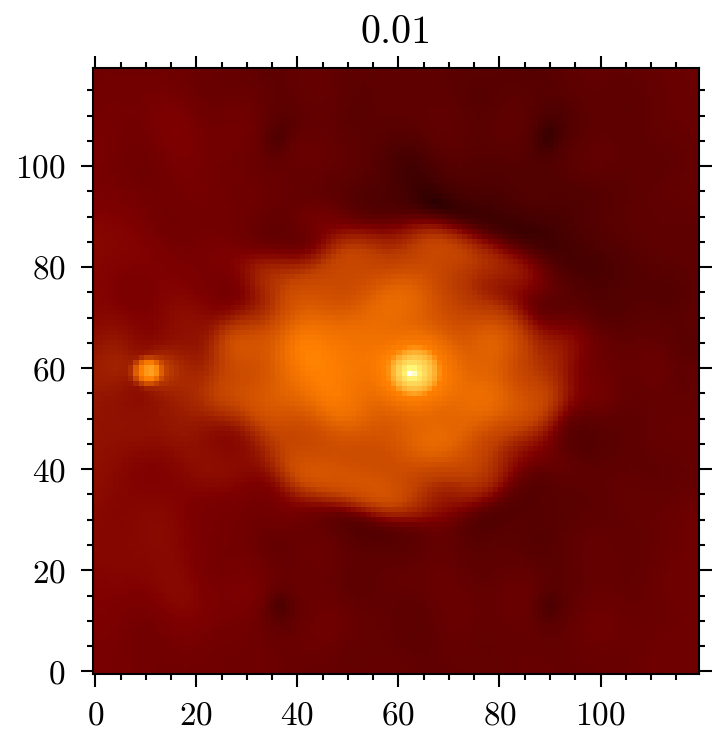

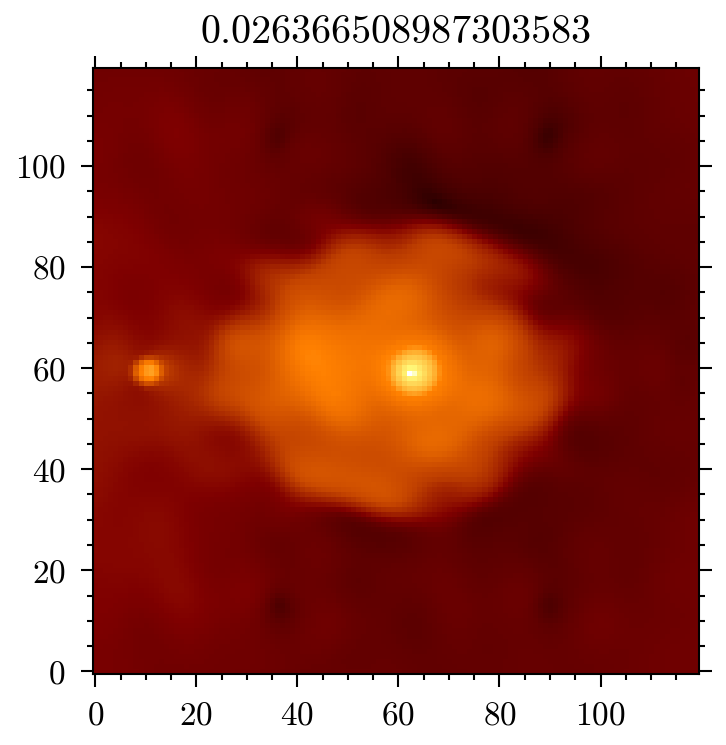

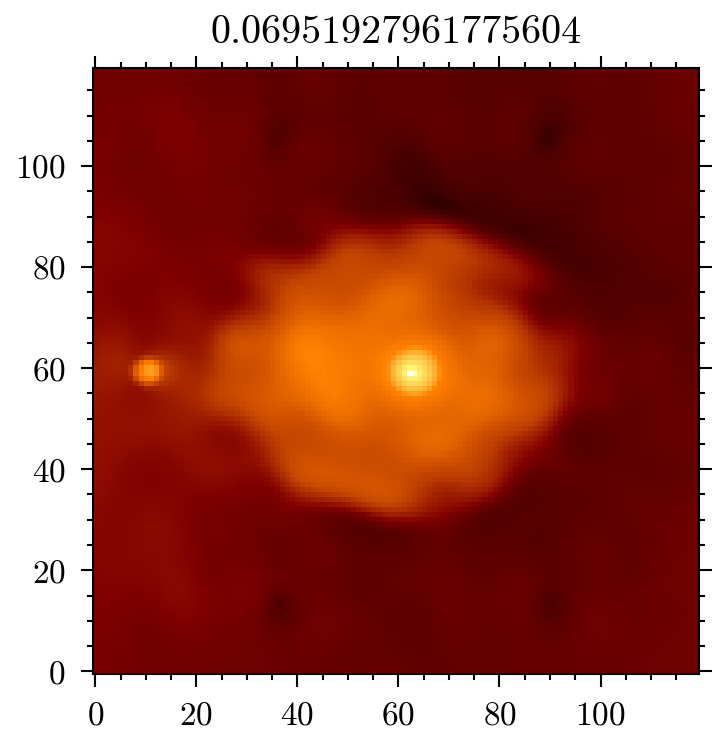

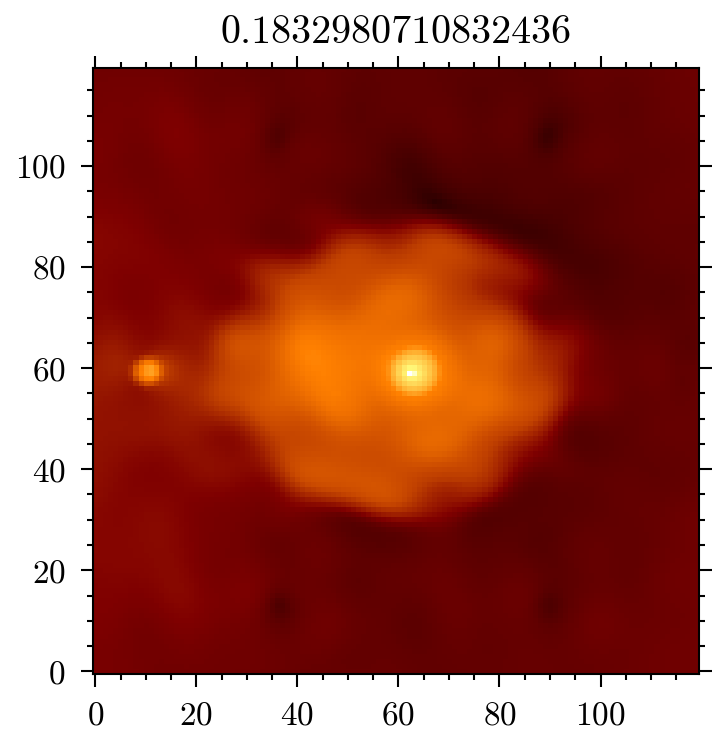

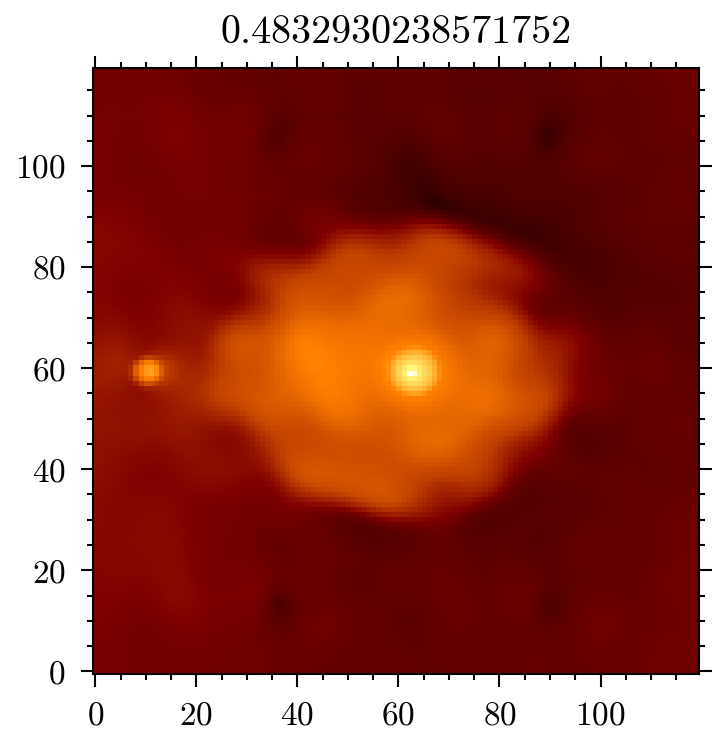

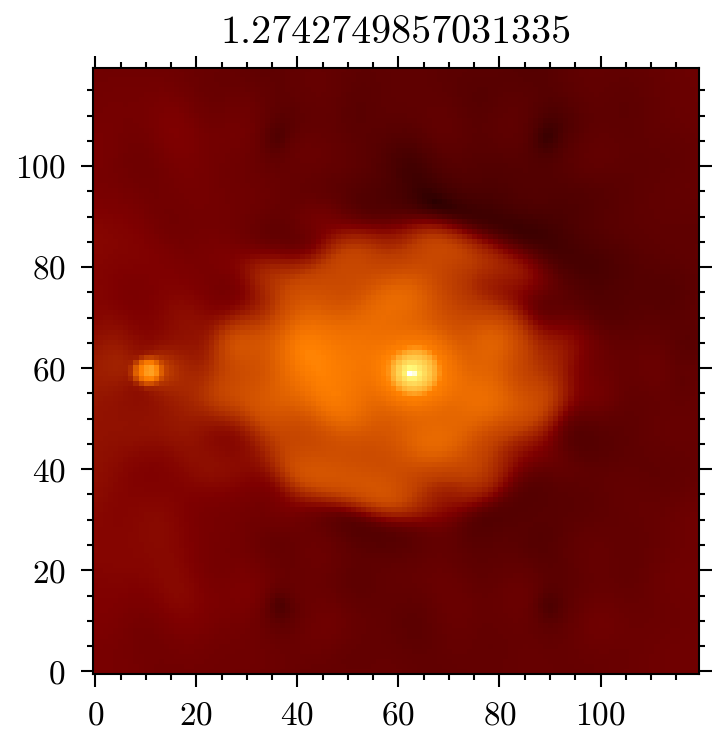

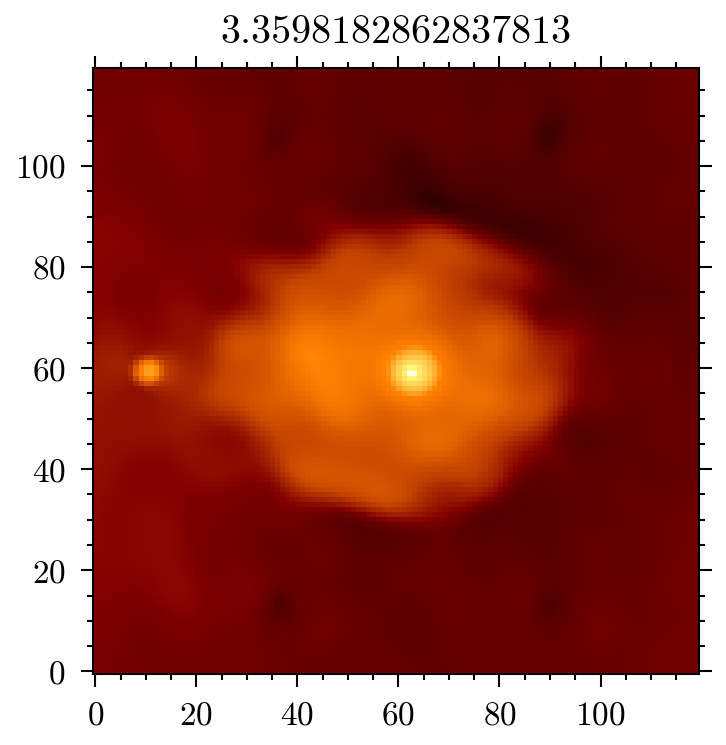

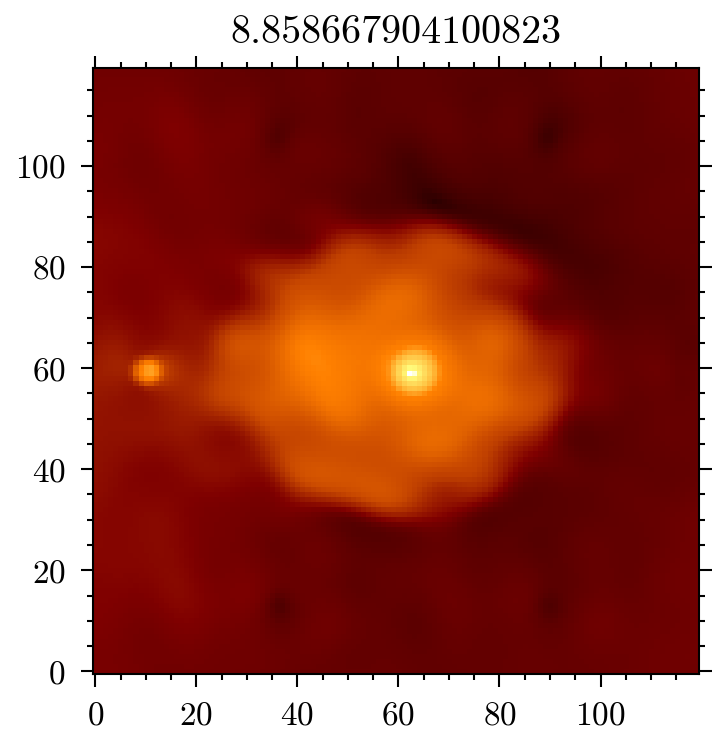

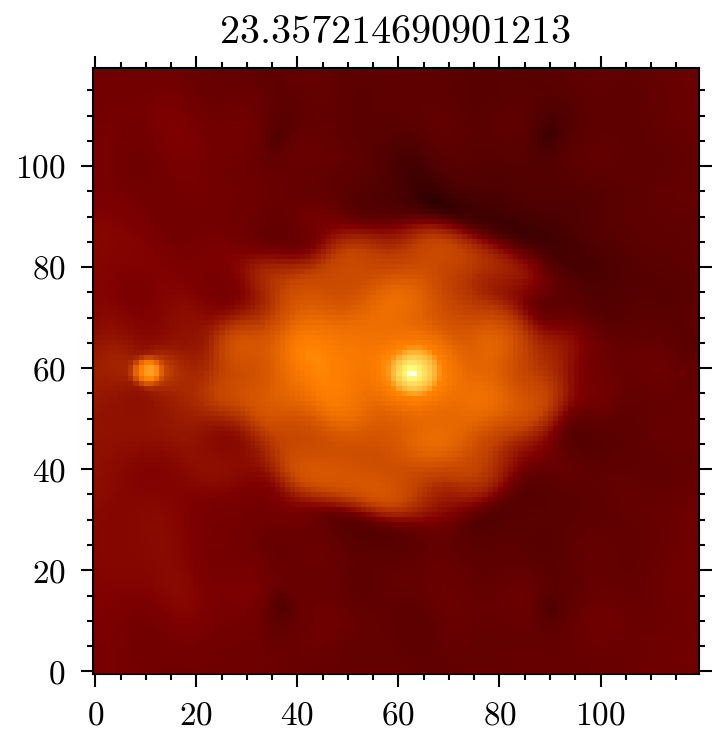

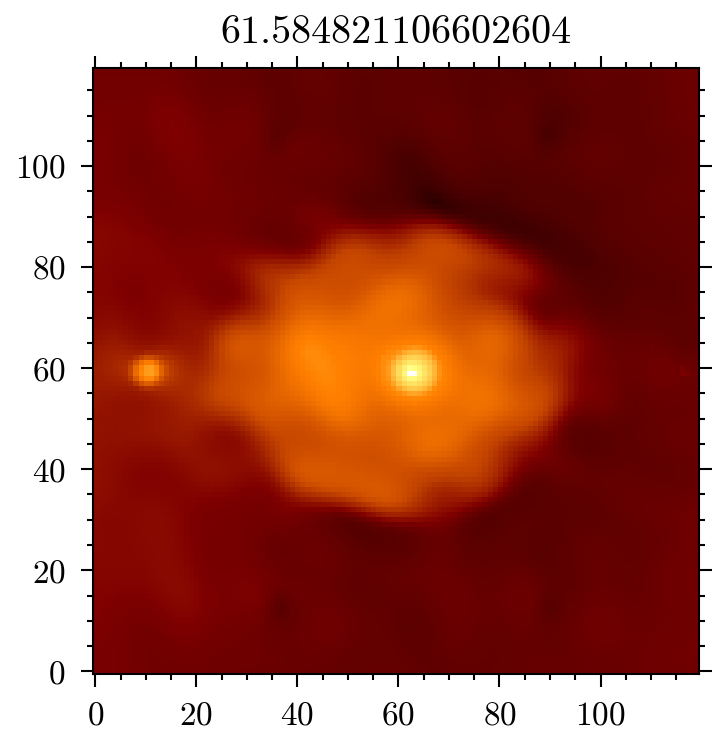

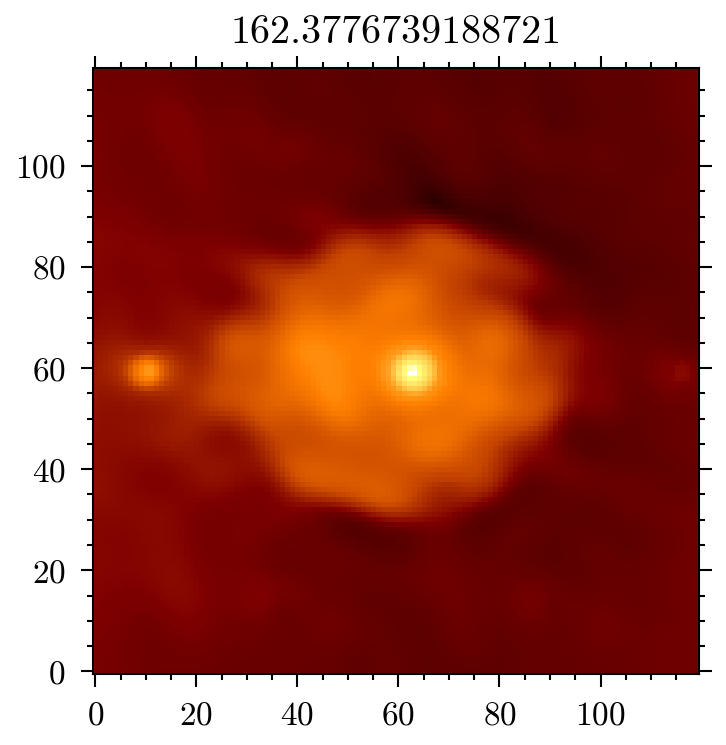

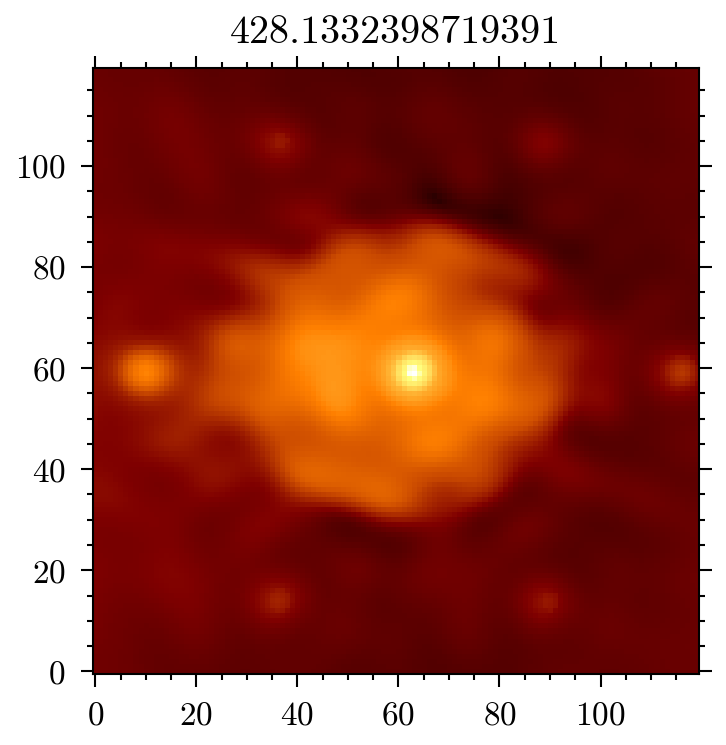

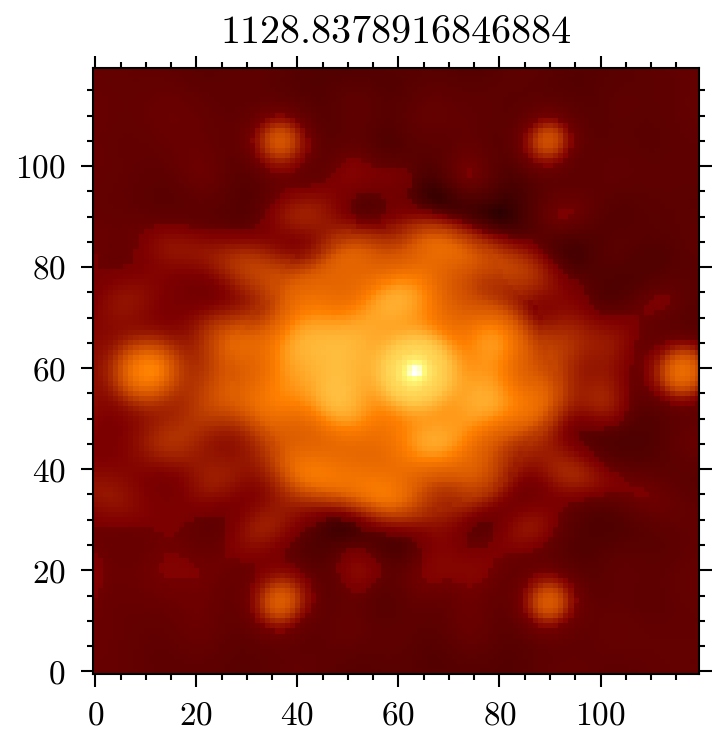

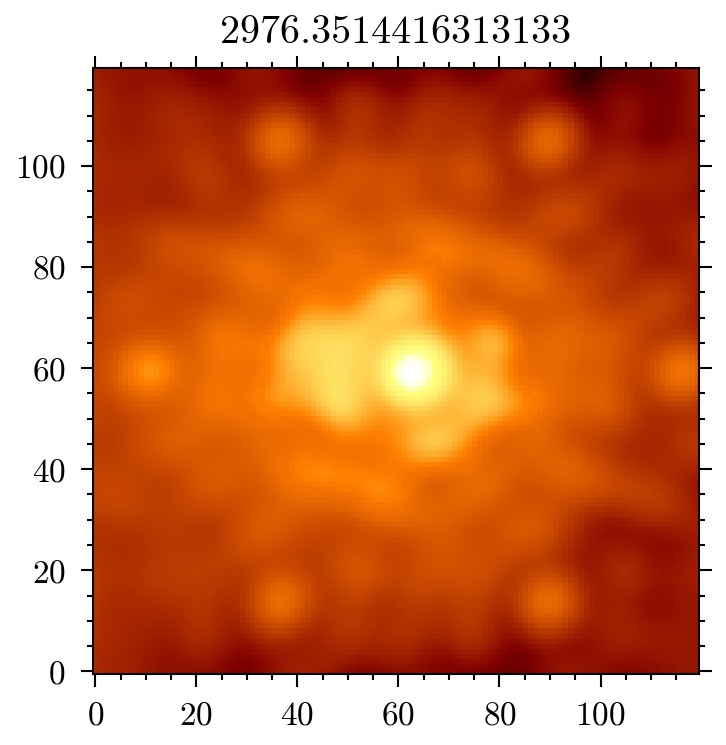

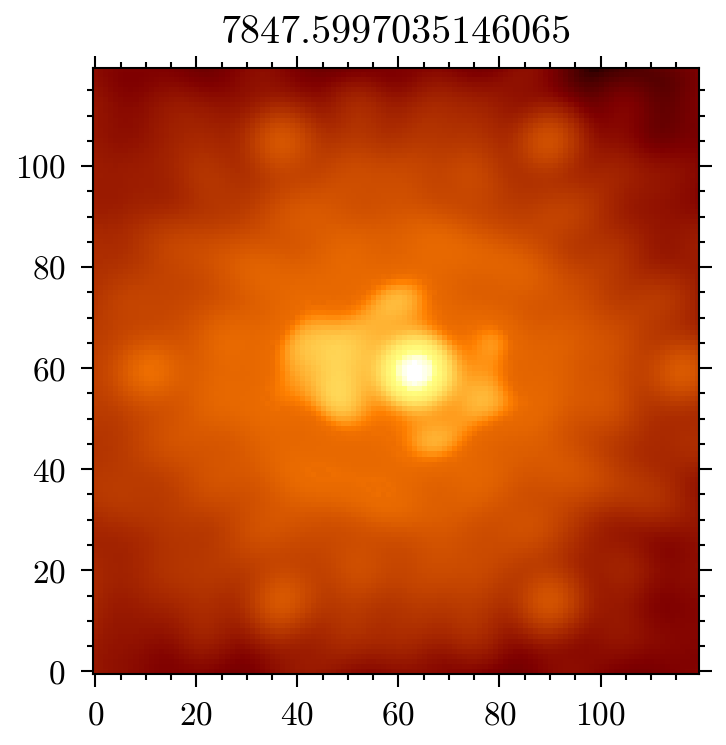

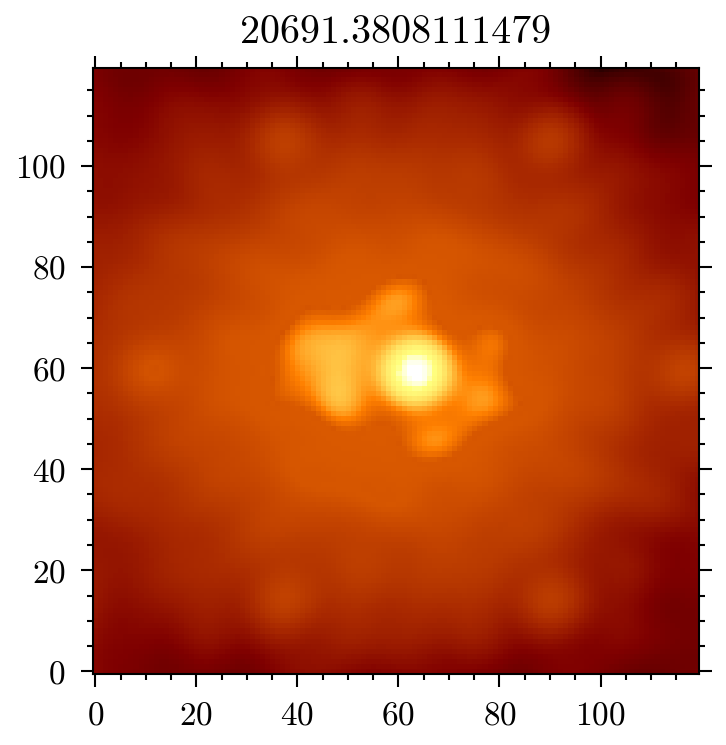

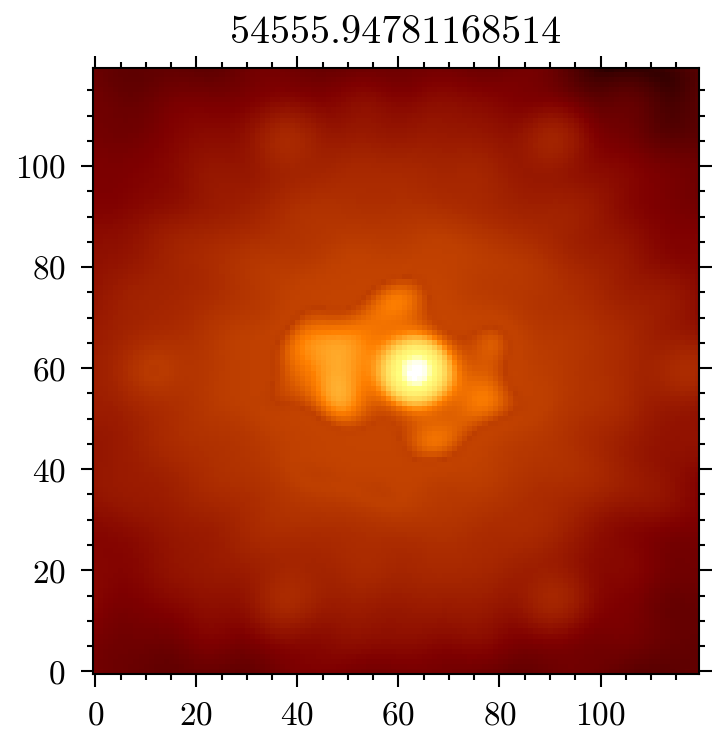

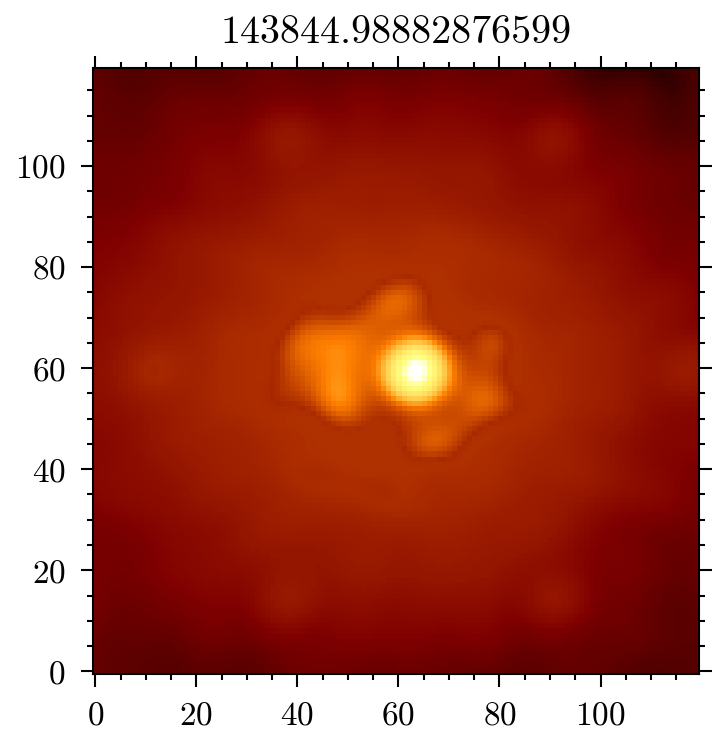

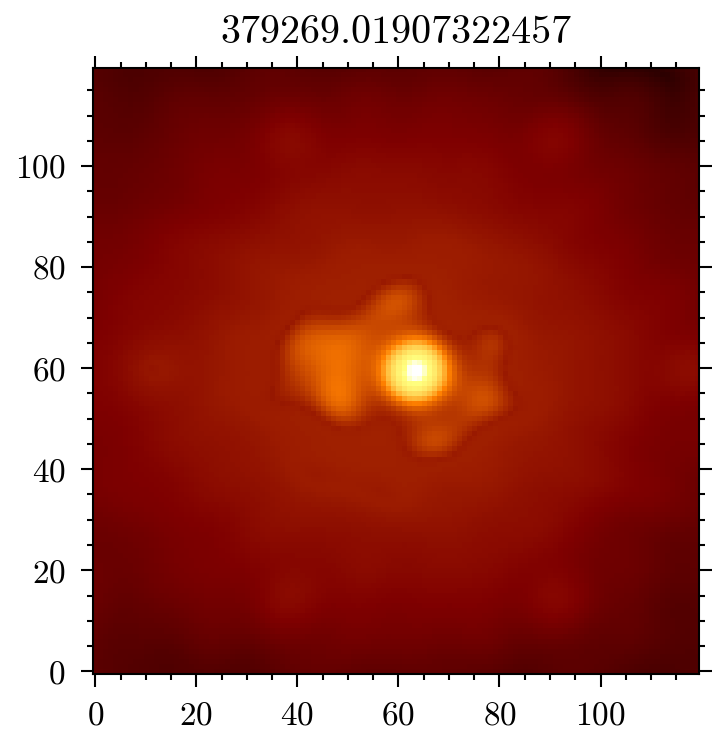

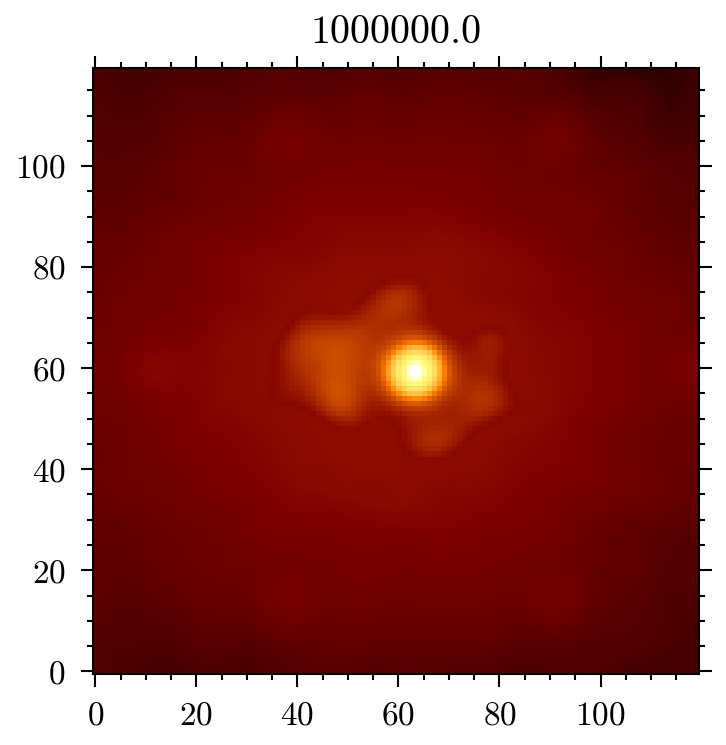

In [ ]:
for i, l in enumerate(log_dists):
    plt.imshow(l["F480M"], norm=mpl.colors.PowerNorm(0.5), cmap="afmhot_10u")
    plt.title(coeffs[i])
    plt.show()

In [ ]:
s2 = sweep - sweep.min() + 1

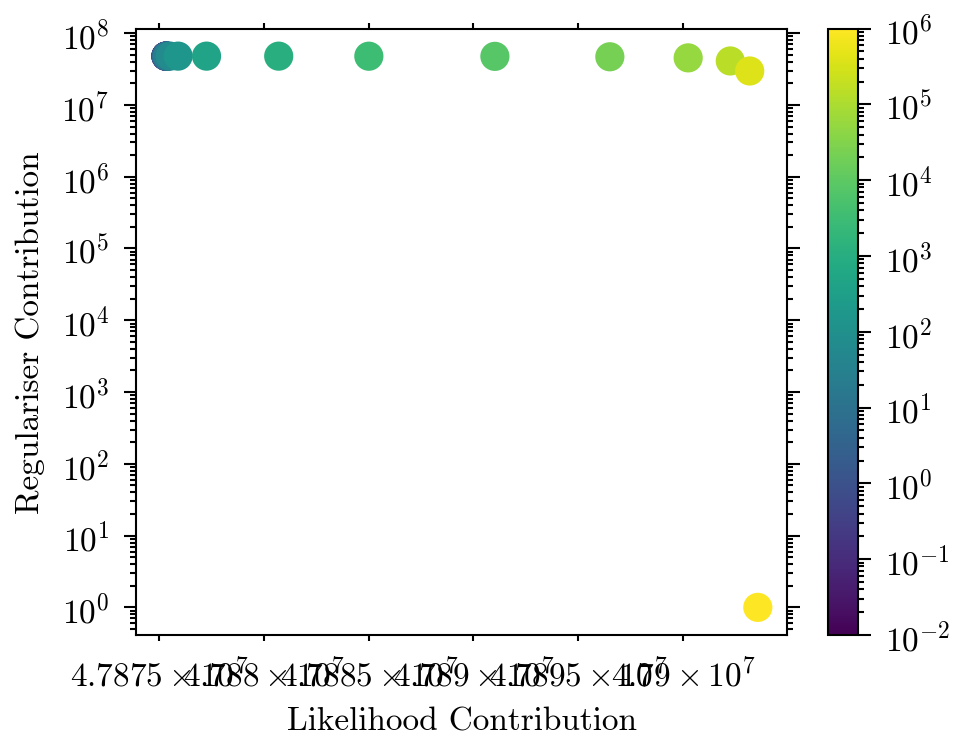

In [ ]:
plt.figure()
plt.scatter(s2[0], s2[1], c=coeffs, cmap="viridis", norm=mpl.colors.LogNorm())
plt.xscale("log")
plt.yscale("log")
plt.colorbar()
plt.xlabel("Likelihood Contribution")
plt.ylabel("Regulariser Contribution")
plt.show()

In [ ]:
final_model, losses, state, histories = amigo.fitting.optimise(
    model,
    # pds_sci_exposures,
    fits,
    fishers=fishers,
    optimisers=config,
    args=args,
    norm_fn=dorito.stats.normalise_wavelets,
    # norm_fn=dorito.stats.normalise_distribution,
    loss_fn=dorito.stats.regularised_loss_fn,
    epochs=n_epoch,
    print_grads=False,
)

balance = dorito.stats.prior_data_loss(final_model, fits[-1], args)
print(f"Likelihood: {balance[0]:.3e}, Prior: {balance[1]:.3e}")

  0%|          | 0/300 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...


In [ ]:
# np.save(init_state_cache + "F480M_120.npy", state.params)

flag = False
for exp in fits:

    try:
        if not flag:
            dist = final_model.get_distribution(exp)

            fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

            c0 = dorito.plotting.plot_result(
                ax[0],
                dist,
                roll_angle_degrees=-rolls[exp.filename],
                cmap="afmhot_10u",
                power=0.3,
                # model=final_model,
                vmin=None,
                # show_diff_lim=True,
                # vmax=io_peak_flux,
            )

            c1 = dorito.plotting.plot_result(
                ax[1],
                dorito.misc.blur_distribution(dist, final_model, exp, factor=0.5),
                cmap="afmhot_10u",
                power=0.3,
                roll_angle_degrees=-rolls[exp.filename],
                # model=hdb_final_model,
            )
            fig.colorbar(c1, ax=ax[1])

            fig.colorbar(c0)
            ax[0].set_title(f"NGC1068 - {exp.filter}")
            ax[1].set(title=r"Convolved - $\lambda / 2D$")

            plt.tight_layout()
            # plt.savefig(save_dir + f"{time}.png", dpi=300)
            # plt.close()
            plt.show()
        flag = True
    except:
        continue


amigo.plotting.plot_losses(losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(histories)

for exp in fits:
    exp.print_summary()
    amigo.plotting.summarise_fit(
        final_model,
        exp,
        # test_model,
    )